# 표 파운데이션 모델을 처음부터 학습하는 작은 실습

합성 표 생성 → Transformer 정의 → 사전학습 → 새 표에서 문맥 내 추론까지 직접 실행합니다. **정식 TabPFN 재현이 아닌, 그 핵심 아이디어를 보여주는 교육용 모델**입니다. 하나의 수치형 입력과 하나의 정답을 사용해 과정을 곡선으로 볼 수 있게 했습니다.

완성된 결과가 포함되어 있어 설치 없이도 읽을 수 있습니다. 직접 학습하려면 Jupyter 또는 Colab에서 위에서 아래로 실행하세요. PDF는 해설용이며 실행 코드는 이 노트북 하나에 들어 있습니다.

이 노트북의 모델은 MSE로 점 예측을 학습합니다. 예측 분포나 보정된 불확실성을 출력하지 않으므로 정식 PFN의 확률적 추론 성질을 그대로 주장할 수 없습니다. [TabPFN 원 논문](https://arxiv.org/abs/2207.01848)의 합성 문제 사전학습과 ICL 아이디어를 참고했습니다.

## 필요한 패키지 설치
이미 설치되어 있다면 건너뜁니다. 아래 줄의 주석을 제거해 실행하세요. CPU만으로도 전체 학습이 가능합니다.

In [1]:
# %pip install torch numpy pandas matplotlib

## 1 실행 환경과 재현성
Python 3.10 이상, PyTorch, NumPy, pandas, matplotlib을 사용합니다. 기본 설정은 CPU이며 사전학습 가중치를 다운로드하지 않습니다. 새로 초기화한 모델을 직접 학습합니다. 난수 시드는 초기 가중치·학습 표·검증 표·평가 표를 구분합니다. 하드웨어와 패키지 버전에 따라 시간과 결과가 조금 달라질 수 있습니다.

아래 `results` 폴더에 학습 기록과 가중치가 저장됩니다. GPU를 쓰려면 PyTorch에 맞는 CUDA 환경을 준비한 뒤 DEVICE를 바꾸세요.

In [2]:
import copy
import json
import math
import time
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch import nn

SEED = 7
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.set_num_threads(2)
DEVICE = 'cpu'  # 학습 흐름을 비교하기 쉽도록 CPU를 기본값으로 사용
OUT = Path('results')
OUT.mkdir(exist_ok=True)


## 2 여러 개의 표 문제 만들기
하나의 큰 표를 배치로 나누는 것과 다릅니다. **배치의 각 원소가 서로 다른 규칙을 가진 표 하나**입니다.

$$y=a+bx+cx^2+\epsilon$$

각 표에서 a, b를 표준정규분포에서 새로 뽑고 c는 표준편차 0.7인 정규분포에서 뽑습니다. x는 [-1, 1]에서, 잡음 ε는 표준편차 0.05인 정규분포에서 생성합니다. 같은 표 안에서는 a, b, c를 공유하지만 다음 표에서는 바뀝니다. x는 정규화한 공정 조건, y는 응답이라고 상상할 수 있습니다. 실제 소재 물성식은 아닙니다.

**한 표에서** 앞의 행들은 관측용 context, 나머지는 질문용 query로 나눕니다. 함수는 질문의 정답도 반환하지만, 그 정답은 손실 계산에만 씁니다. 모델에 a, b, c는 전달하지 않습니다.

| 텐서 | 모양 | 의미 |
|---|---|---|
| x_context | [B, C, 1] | B개 표의 관측 조건 C개 |
| y_context | [B, C, 1] | 관측 결과 |
| x_query | [B, Q, 1] | 맞혀야 할 조건 Q개 |
| y_query | [B, Q] | 손실 계산용 정답 |

B=32이면 32개의 다른 규칙을 동시에 풉니다. 한 표의 행들이 서로 다른 규칙을 갖게 만들면 관측으로 규칙을 추론하는 문제가 성립하지 않습니다.

In [3]:
# 하나의 배치 원소가 하나의 독립적인 '표 문제'입니다.
def sample_tasks(batch_size, n_context, n_query, generator):
    coefficients = torch.randn(batch_size, 3, generator=generator)
    coefficients[:, 2] *= 0.7
    x = 2 * torch.rand(batch_size, n_context + n_query, 1, generator=generator) - 1
    clean_y = (coefficients[:, 0, None] + coefficients[:, 1, None] * x[..., 0]
               + coefficients[:, 2, None] * x[..., 0] ** 2)
    y = clean_y + 0.05 * torch.randn(clean_y.shape, generator=generator)
    return (x[:, :n_context].to(DEVICE), y[:, :n_context, None].to(DEVICE),
            x[:, n_context:].to(DEVICE), y[:, n_context:].to(DEVICE))


### 한 표의 실제 숫자 확인
아래 hidden_y는 학습 프로그램만 아는 채점용 정답입니다. forward 입력에는 전달하지 않습니다.

In [4]:
preview_gen = torch.Generator().manual_seed(505)
pxc, pyc, pxq, pyq = sample_tasks(1, 4, 2, preview_gen)
print("관측 행: 모델에 x와 y를 함께 제공합니다.")
print(pd.DataFrame({"x": pxc[0, :, 0].cpu(), "y": pyc[0, :, 0].cpu()}).round(3).to_string(index=False))
print("질문 행: 모델에는 x만, loss 계산에는 정답 y를 사용합니다.")
print(pd.DataFrame({"x_query": pxq[0, :, 0].cpu(), "hidden_y": pyq[0].cpu()}).round(3).to_string(index=False))


관측 행: 모델에 x와 y를 함께 제공합니다.
     x     y
 0.480 0.769
 0.911 1.660
-0.071 0.476
-0.893 1.206
질문 행: 모델에는 x만, loss 계산에는 정답 y를 사용합니다.
 x_query  hidden_y
   0.544     0.912
  -0.777     1.044


## 3 작은 Transformer 직접 정의하기
관측 행은 `[x, y, 1]`, 질문 행은 `[x, 0, 0]`으로 만듭니다. 마지막 숫자는 정답을 알고 있는지 나타내는 표시입니다. 관측 y가 실제로 0인 경우와 질문의 임시 0을 구별할 수 있습니다.

3개 숫자를 Linear 층으로 48차원 토큰으로 바꿉니다. 위치 임베딩은 사용하지 않습니다. 관측 행 순서가 바뀌어도 같은 표로 처리하려는 설계입니다.

**구조:** 입력 임베딩 → Transformer 블록 2개 → LayerNorm → 행별 숫자 예측. 각 블록은 4개 Attention head와 폭 96의 MLP를 사용합니다. 모델을 작게 하고 관측 순열 검증을 단순하게 만들기 위해 dropout은 0으로 둡니다.

$$\mathrm{Attention}(Q,K,V)=\mathrm{softmax}(QK^T/\sqrt{d_k}+M)V$$

Attention 마스크는 모든 행이 관측 행만 Key/Value로 보도록 합니다.

| 읽는 행 / 참조하는 열 | 관측 행 | 질문 행 |
|---|---|---|
| 관측 행 | 허용 | 차단 |
| 질문 행 | 허용 | 차단 |

질문 행은 자기 x를 잔차 경로로 유지합니다. 질문끼리 정보를 주고받지 않으므로 한꺼번에 넣는 질문 수가 달라져도 각 예측이 같아야 합니다. 이 설계는 교육용 선택이며 모든 TFM에 의무적인 구조는 아닙니다.

**주의:** 함수 인자에 `y_query`가 없습니다. 마스크만으로 누출을 막으려 하지 않고, 정답이 모델에 들어갈 경로 자체를 없앴습니다. PyTorch에서 이 Boolean 마스크의 True는 차단을 의미합니다. [TransformerEncoderLayer 공식 문서](https://docs.pytorch.org/docs/stable/generated/torch.nn.TransformerEncoderLayer.html)

In [5]:
class TinyTableTransformer(nn.Module):
    def __init__(self, width=48, n_heads=4, n_layers=2):
        super().__init__()
        self.embedding = nn.Linear(3, width)
        layer = nn.TransformerEncoderLayer(
            d_model=width, nhead=n_heads, dim_feedforward=width * 2,
            dropout=0.0, batch_first=True, norm_first=True,
            activation='gelu')
        self.encoder = nn.TransformerEncoder(
            layer, num_layers=n_layers, enable_nested_tensor=False)
        # 복제된 층이 서로 다른 초기 가중치를 갖도록 재초기화합니다.
        for block in self.encoder.layers:
            for param in block.parameters():
                if param.ndim > 1:
                    nn.init.xavier_uniform_(param)
        self.head = nn.Sequential(nn.LayerNorm(width), nn.Linear(width, 1))

    def forward(self, x_context, y_context, x_query):
        n_context = x_context.shape[1]
        context = torch.cat([x_context, y_context, torch.ones_like(y_context)], dim=-1)
        # 질문 정답은 이 함수의 인자로도 받지 않습니다.
        query = torch.cat([x_query, torch.zeros_like(x_query),
                           torch.zeros_like(x_query)], dim=-1)
        tokens = torch.cat([context, query], dim=1)
        length = tokens.shape[1]
        # True는 '볼 수 없음'. 모든 행은 관측 행만 Key/Value로 봅니다.
        mask = torch.zeros(length, length, dtype=torch.bool, device=tokens.device)
        mask[:, n_context:] = True
        hidden = self.encoder(self.embedding(tokens), mask=mask)
        return self.head(hidden[:, n_context:]).squeeze(-1)


## 4 사전학습과 역전파
한 번의 학습 단계는 다음 순서입니다.

1. 서로 다른 규칙의 표 32개를 생성합니다.
2. 관측 행과 질문 조건을 모델에 넣습니다.
3. 질문 예측과 숨겨 둔 정답 사이의 MSE를 구합니다.
4. `zero_grad()`로 이전 기울기를 지우고 `backward()`로 새 기울기를 계산합니다.
5. `optimizer.step()`으로 공통 가중치 θ를 업데이트합니다.

$$L=\frac{1}{BQ}\sum_{b=1}^{B}\sum_{j=1}^{Q}(\hat y_{bj}-y_{bj})^2$$

손실은 질문 행에서 계산하지만 기울기는 Attention을 거쳐 관측 행을 처리하는 층에도 전달됩니다. 즉, 관측 결과에서 유용한 정보를 추출하도록 임베딩과 Attention, MLP가 함께 바뀝니다. 합성 데이터를 만든 a, b, c를 학습하는 것이 아닙니다.

1800단계 × 배치 32 = **57,600개 합성 표 문제**를 만납니다. 관측 수는 2, 4, 8, 16을 순환합니다. 매번 새 표를 생성하므로 정해진 데이터셋을 한 바퀴 도는 epoch보다 optimizer step이 적절한 기준입니다.

검증은 별도의 고정된 표 64개로 수행합니다. 검증 데이터로 역전파하지 않으며 이 예제에서는 체크포인트 선택에도 쓰지 않습니다. 학습 배치 손실은 관측 수와 문제가 바뀌어 출렁일 수 있습니다. 최종 1800단계 모델을 평가합니다.

`N_STEPS=100`은 빠른 동작 확인용이며 충분한 학습 결과를 기대해서는 안 됩니다. 학습 셀을 다시 실행하면 새 모델부터 시작합니다.

In [6]:
model = TinyTableTransformer().to(DEVICE)
untrained = copy.deepcopy(model).eval()
optimizer = torch.optim.AdamW(model.parameters(), lr=0.0005, weight_decay=0.0001)
train_gen = torch.Generator().manual_seed(101)
validation_gen = torch.Generator().manual_seed(202)
validation = sample_tasks(64, 8, 16, validation_gen)
N_STEPS = 1800  # 처음에는 100으로 줄여 동작만 확인해도 됩니다.
BATCH_SIZE = 32
history = []
start = time.perf_counter()
for step in range(1, N_STEPS + 1):
    model.train()
    n_context = [2, 4, 8, 16][(step - 1) % 4]
    xc, yc, xq, yq = sample_tasks(BATCH_SIZE, n_context, 16, train_gen)
    prediction = model(xc, yc, xq)
    loss = nn.functional.mse_loss(prediction, yq)
    optimizer.zero_grad()
    loss.backward()
    nn.utils.clip_grad_norm_(model.parameters(), 1.0)
    optimizer.step()
    if step == 1 or step % 100 == 0:
        model.eval()
        with torch.no_grad():
            val_loss = nn.functional.mse_loss(model(*validation[:3]), validation[3]).item()
        history.append({'step': step, 'train_batch_mse': loss.item(), 'validation_mse': val_loss})
        print(f'{step:4d}/{N_STEPS}  train={loss.item():.4f}  validation={val_loss:.4f}', flush=True)
elapsed = time.perf_counter() - start
model.eval()
print(f'Parameters: {sum(p.numel() for p in model.parameters()):,}; time: {elapsed:.1f}s')


   1/1800  train=1.0140  validation=0.8284
 100/1800  train=0.0665  validation=0.1236
 200/1800  train=0.0338  validation=0.0780
 300/1800  train=0.0310  validation=0.0753
 400/1800  train=0.0151  validation=0.0576
 500/1800  train=0.0198  validation=0.0586
 600/1800  train=0.0154  validation=0.0568
 700/1800  train=0.0246  validation=0.0436
 800/1800  train=0.0196  validation=0.0574
 900/1800  train=0.0160  validation=0.0454
1000/1800  train=0.0248  validation=0.0484
1100/1800  train=0.0118  validation=0.0459
1200/1800  train=0.0091  validation=0.0534
1300/1800  train=0.0108  validation=0.0456
1400/1800  train=0.0112  validation=0.0442
1500/1800  train=0.0133  validation=0.0471
1600/1800  train=0.0109  validation=0.0393
1700/1800  train=0.0159  validation=0.0411
1800/1800  train=0.0104  validation=0.0295
Parameters: 38,257; time: 14.8s


## 5 처음 보는 표에서 평가하기
여기부터 `no_grad()` 안에서만 예측합니다. 새로운 표 128개를 만들고, 각 표에 같은 질문 32개를 둡니다. 관측은 처음 2개 → 4개 → 8개 → 16개로 누적하므로 같은 문제에서 관측 수의 영향을 비교할 수 있습니다.

비교 대상은 초기 무작위 Transformer, 사전학습 Transformer, 관측 y의 평균, 다른 표의 y를 잘못 연결한 문맥, 2차 다항식 ridge 회귀입니다. 마지막 모델은 생성 규칙이 2차식이라는 강한 정보를 미리 받습니다. 이 모델을 이기는 것이 실습 목표가 아닙니다.

잘못된 문맥 비교는 x를 유지하고 표 사이에서 y를 순환시킵니다. 성능이 나빠지면 관측 정답에 의존한다는 증거가 되지만, 특정 인과 메커니즘을 이해했다는 증명은 아닙니다.

점수는 잡음이 있는 질문 정답에 대한 MSE입니다. 표별 MSE의 평균과 표준오차를 보고합니다. 표준오차는 이 128개 문제에서의 변동이며 여러 번 다시 학습했을 때의 변동을 포함하지 않습니다.

In [7]:
# 학습 및 검증과 독립적인 난수 계열로 새 표를 만듭니다.
test_gen = torch.Generator().manual_seed(303)
xc_all, yc_all, xq, yq = sample_tasks(128, 16, 32, test_gen)
rows = []
with torch.no_grad():
    for n in [2, 4, 8, 16]:
        xc, yc = xc_all[:, :n], yc_all[:, :n]
        predictions = {
            'Untrained Transformer': untrained(xc, yc, xq),
            'Pretrained Transformer': model(xc, yc, xq),
            'Context mean': yc.mean(dim=1).expand(-1, xq.shape[1]),
            'Wrong context labels': model(xc, yc.roll(1, dims=0), xq),
        }
        # 합성 규칙의 기저를 아는 강력한 비교 기준입니다. 실무의 만능 모델은 아닙니다.
        A = torch.cat([torch.ones_like(xc), xc, xc**2], dim=-1)
        Q = torch.cat([torch.ones_like(xq), xq, xq**2], dim=-1)
        ridge = 0.01 * torch.eye(3, device=DEVICE)[None]
        beta = torch.linalg.solve(A.transpose(1, 2) @ A + ridge, A.transpose(1, 2) @ yc)
        predictions['Quadratic ridge (known basis)'] = (Q @ beta).squeeze(-1)
        for name, pred in predictions.items():
            task_mse = ((pred - yq)**2).mean(dim=1)
            rows.append({'n_context': n, 'model': name, 'MSE': task_mse.mean().item(),
                         'task_MSE_SE': task_mse.std().item() / np.sqrt(len(task_mse))})
scores = pd.DataFrame(rows)
print(scores.round(5).to_string(index=False))


 n_context                         model     MSE  task_MSE_SE
         2         Untrained Transformer 1.14902      0.11734
         2        Pretrained Transformer 0.16033      0.01978
         2                  Context mean 0.54193      0.05740
         2          Wrong context labels 3.34738      0.38439
         2 Quadratic ridge (known basis) 0.14863      0.01950
         4         Untrained Transformer 1.18554      0.11524
         4        Pretrained Transformer 0.04774      0.00717
         4                  Context mean 0.48360      0.05259
         4          Wrong context labels 2.75986      0.33362
         4 Quadratic ridge (known basis) 0.03356      0.01030
         8         Untrained Transformer 1.19084      0.11632
         8        Pretrained Transformer 0.01569      0.00287
         8                  Context mean 0.44157      0.04417
         8          Wrong context labels 2.50719      0.29063
         8 Quadratic ridge (known basis) 0.00485      0.00049
        

## 6 가중치를 바꾸지 않았는지 확인하기
예측 전후의 `state_dict()`를 비교해 모든 값이 같은지 확인합니다. 또한 관측 행과 정답을 같은 순서로 뒤집어 예측이 유지되는지, 질문 하나만 넣어도 결과가 유지되는지 검사합니다.

`eval()`은 dropout 등의 동작 모드를 바꾸고, `no_grad()`는 기울기 기록을 끕니다. 실제 업데이트는 optimizer가 담당합니다. 이 단계에는 `backward()`나 `optimizer.step()`이 없습니다. 새로운 정보는 가중치가 아니라 입력과 내부 활성값에 반영됩니다.

In [8]:
before = {k: v.clone() for k, v in model.state_dict().items()}
with torch.no_grad():
    original = model(xc_all[:, :8], yc_all[:, :8], xq)
    permutation = torch.arange(7, -1, -1)
    permuted = model(xc_all[:, :8][:, permutation], yc_all[:, :8][:, permutation], xq)
    # 다른 질문 행을 제거해도 예측이 같은지 확인합니다.
    one_query = model(xc_all[:, :8], yc_all[:, :8], xq[:, :1])
checks = {
    'weights_unchanged': all(torch.equal(before[k], v) for k, v in model.state_dict().items()),
    'row_permutation_max_abs_difference': (original - permuted).abs().max().item(),
    'query_batch_max_abs_difference': (original[:, :1] - one_query).abs().max().item(),
}
assert checks['weights_unchanged']
assert checks['row_permutation_max_abs_difference'] < 1e-4
assert checks['query_batch_max_abs_difference'] < 1e-4
print(checks)


{'weights_unchanged': True, 'row_permutation_max_abs_difference': 9.5367431640625e-07, 'query_batch_max_abs_difference': 9.5367431640625e-07}


## 7 같은 가중치에 관측을 추가하면
한 개의 가상 실험 규칙 `y=0.4+0.7x−0.9x²`를 정해 관측을 누적합니다. 회색 점선은 우리가 알고 있는 생성 규칙이며, 모델에는 그 식을 알려주지 않습니다. 주황색 점은 관측, 청록색 선은 고정된 모델의 예측입니다.

회색 배경의 x < −1 또는 x > 1은 사전학습 때 보지 않은 입력 범위입니다. 그 영역의 오차는 외삽 한계를 관찰하기 위한 것이며, 위 정량 평가의 MSE에는 포함되지 않습니다. 관측이 늘어도 특정 구간의 오차가 반드시 단조롭게 줄지는 않습니다.

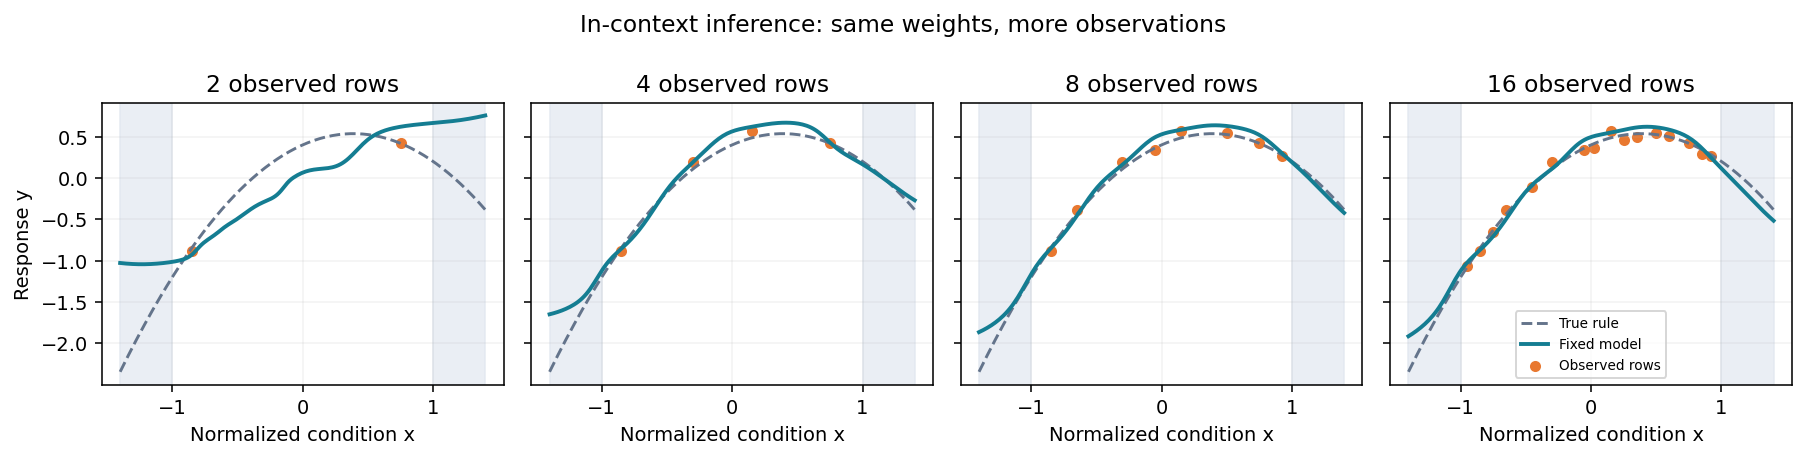

In [9]:
# 관측값을 누적해서 추가합니다. 실제 곡선은 평가에만 사용합니다.
grid = torch.linspace(-1.4, 1.4, 180).reshape(1, -1, 1).to(DEVICE)
context_x = torch.tensor([-0.85, 0.75, -0.3, 0.15, -0.65, 0.5, -0.05, 0.92,
                          -0.95, 0.35, -0.45, 0.6, 0.02, 0.85, -0.75, 0.25]).reshape(1, -1, 1).to(DEVICE)
def demo_function(x):
    return 0.4 + 0.7 * x - 0.9 * x**2
noise_gen = torch.Generator().manual_seed(404)
context_y = demo_function(context_x) + 0.05 * torch.randn(context_x.shape, generator=noise_gen).to(DEVICE)
fig, axes = plt.subplots(1, 4, figsize=(13, 3.3), sharey=True)
with torch.no_grad():
    for ax, n in zip(axes, [2, 4, 8, 16]):
        pred = model(context_x[:, :n], context_y[:, :n], grid)[0].cpu().numpy()
        ax.plot(grid[0, :, 0].cpu(), demo_function(grid)[0, :, 0].cpu(), color='#64748b', ls='--', label='True rule')
        ax.plot(grid[0, :, 0].cpu(), pred, color='#147d92', lw=2, label='Fixed model')
        ax.scatter(context_x[0, :n, 0].cpu(), context_y[0, :n, 0].cpu(), c='#e87830', s=22, label='Observed rows')
        ax.axvspan(-1.4, -1, color='#e2e8f0', alpha=0.7)
        ax.axvspan(1, 1.4, color='#e2e8f0', alpha=0.7)
        ax.set_title(f'{n} observed rows'); ax.set_xlabel('Normalized condition x'); ax.grid(alpha=0.15)
axes[0].set_ylabel('Response y'); axes[-1].legend(fontsize=7)
fig.suptitle('In-context inference: same weights, more observations', fontsize=12)
fig.tight_layout(); fig.savefig(OUT/'context_growth.png', dpi=180); plt.show()


## 8 학습 곡선 읽기
고정 검증 문제에서 오차가 줄어드는지 봅니다. 초기 모델과 사전학습 모델의 평가 차이는 사전학습 효과, 같은 모델에서 관측 수에 따른 차이는 문맥 내 적응 효과입니다. 서로 다른 두 효과를 구분하세요. 종축은 로그 척도입니다.

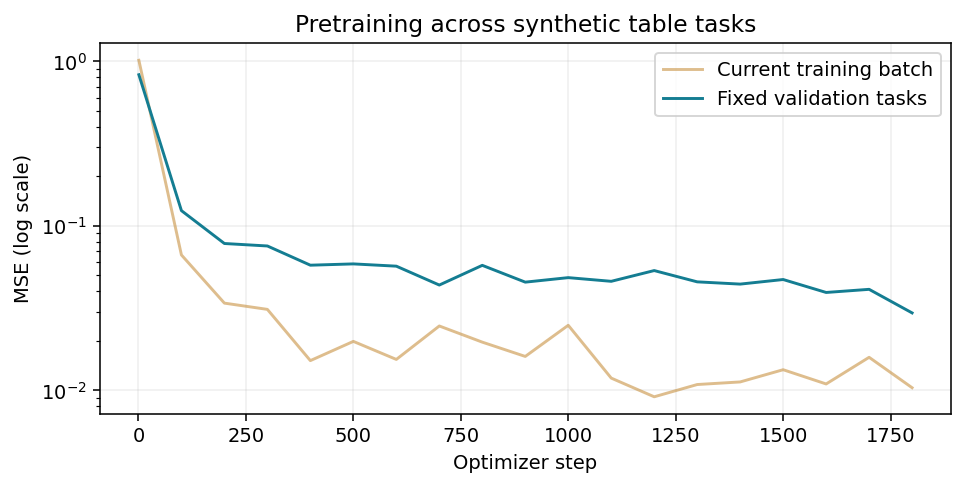

In [10]:
h = pd.DataFrame(history)
fig, ax = plt.subplots(figsize=(7, 3.6))
ax.plot(h.step, h.train_batch_mse, color='#c89242', alpha=0.6, label='Current training batch')
ax.plot(h.step, h.validation_mse, color='#147d92', label='Fixed validation tasks')
ax.set_yscale('log'); ax.set_xlabel('Optimizer step'); ax.set_ylabel('MSE (log scale)')
ax.set_title('Pretraining across synthetic table tasks'); ax.legend(); ax.grid(alpha=0.2)
fig.tight_layout(); fig.savefig(OUT/'training_curve.png', dpi=180); plt.show()


## 9 결과와 가중치 저장하기
학습 기록, 평가 수치, 버전, 시드, 실제 소요 시간, 검사 결과와 작은 모델 가중치를 저장합니다. 결과를 재현할 때는 노트북 전체와 환경 기록을 함께 보관하세요. 동일 시드여도 다른 하드웨어나 라이브러리에서는 작은 수치 차이가 있을 수 있습니다.

In [11]:
h.to_csv(OUT/'training_history.csv', index=False)
scores.to_csv(OUT/'evaluation.csv', index=False)
torch.save({'state_dict': model.state_dict(), 'width': 48, 'n_heads': 4, 'n_layers': 2}, OUT/'tiny_table_transformer.pt')
metadata = {'torch':torch.__version__, 'numpy':np.__version__, 'seed':SEED, 'steps':N_STEPS,
            'batch_size':BATCH_SIZE, 'synthetic_training_tasks':N_STEPS*BATCH_SIZE,
            'parameters':sum(p.numel() for p in model.parameters()), 'elapsed_seconds':elapsed,
            'device':DEVICE, 'checks':checks}
(OUT/'run_metadata.json').write_text(json.dumps(metadata, indent=2), encoding='utf-8')
print(json.dumps(metadata, indent=2))


{
  "torch": "2.14.0+cpu",
  "numpy": "2.3.5",
  "seed": 7,
  "steps": 1800,
  "batch_size": 32,
  "synthetic_training_tasks": 57600,
  "parameters": 38257,
  "elapsed_seconds": 14.750920684999983,
  "device": "cpu",
  "checks": {
    "weights_unchanged": true,
    "row_permutation_max_abs_difference": 9.5367431640625e-07,
    "query_batch_max_abs_difference": 9.5367431640625e-07
  }
}


## 10 저장한 모델만 불러와 새 표 예측하기
학습을 다시 하지 않고 실행할 때는 환경 설정 셀과 모델 정의 셀을 먼저 실행한 뒤 아래 셀을 실행합니다. ZIP의 `results/tiny_table_transformer.pt`가 있어야 합니다. 자신이 만든 가중치나 제공된 가중치를 사용하세요.

In [12]:
checkpoint = torch.load(OUT / 'tiny_table_transformer.pt', map_location=DEVICE, weights_only=True)
loaded = TinyTableTransformer(checkpoint['width'], checkpoint['n_heads'], checkpoint['n_layers']).to(DEVICE)
loaded.load_state_dict(checkpoint['state_dict'])
loaded.eval()
new_x = torch.tensor([[[-0.8], [0.0], [0.8]]], device=DEVICE)
new_y = torch.tensor([[[-0.6], [0.4], [1.3]]], device=DEVICE)
question = torch.tensor([[[0.3]]], device=DEVICE)
with torch.no_grad():
    answer = loaded(new_x, new_y, question).item()
print(f'x=0.3에서의 예측: {answer:.4f}')


x=0.3에서의 예측: 0.7842


## 11 바꿔 볼 실험

- 생성 함수를 2차식에서 sin 함수로 바꾸고, 평가도 같은 분포로 맞춰 다시 학습해 보세요.
- 2차식으로 학습한 모델을 sin 함수에 평가해, 분포가 바뀌면 무엇이 달라지는지 확인하세요.
- 새로운 관측값만 바꾸고 optimizer를 호출하지 않은 상태에서 예측이 바뀌는지 확인하세요.
- 입력 특성을 2개로 늘리려면 데이터 생성, 입력 임베딩 차원, 질문 토큰 생성, 비교 모델을 함께 수정해야 합니다. 숫자 하나만 바꾸면 되는 구조는 아닙니다.

이 모델은 실제 소재 예측이나 다음 실험 추천용이 아닙니다. 정식 TFM은 더 다양한 생성 분포, 여러 특성, 결측값과 범주형 처리, 회귀 분포 출력 등 훨씬 많은 설계가 필요합니다.

[TabPFN 원 논문](https://arxiv.org/abs/2207.01848) · [PyTorch TransformerEncoderLayer](https://docs.pytorch.org/docs/stable/generated/torch.nn.TransformerEncoderLayer.html)

## 실행 결과와 해석

실행 환경은 CPU, PyTorch 2.14.0+cpu, NumPy 2.3.5입니다. 모델은 38,257개 파라미터이며 1,800번 업데이트했습니다. 측정된 학습 루프 시간은 14.8초입니다. 설치, 임포트, 그래프 작성 시간은 제외하며 다른 컴퓨터에서 같은 시간을 보장하지 않습니다.

아래는 새로운 표 128개, 각 표의 질문 32개에 대한 MSE입니다. 입력과 정답은 무차원 합성 값입니다.

| 관측 행 수 | 초기 모델 | 사전학습 모델 | 관측 평균 | 2차 ridge | 잘못된 문맥 |
|---:|---:|---:|---:|---:|---:|
| 2 | 1.1490 | 0.1603 | 0.5419 | 0.1486 | 3.3474 |
| 4 | 1.1855 | 0.0477 | 0.4836 | 0.0336 | 2.7599 |
| 8 | 1.1908 | 0.0157 | 0.4416 | 0.0049 | 2.5072 |
| 16 | 1.1842 | 0.0114 | 0.4185 | 0.0031 | 2.2348 |


학습된 모델은 초기 모델과 관측 평균보다 낮은 오차를 보였습니다. 관측이 늘어날 때 평균 오차가 감소했고, 잘못된 문맥을 제공하면 오차가 커졌습니다. 따라서 이 예제에서는 사전학습 효과와 문맥 의존성을 관찰할 수 있습니다.

2차 ridge 회귀가 더 잘 맞습니다. 생성 규칙의 기저를 정확히 아는 비교 모델이므로 자연스러운 결과입니다. Transformer가 더 복잡하다는 이유만으로 이 문제에서 우월할 필요는 없습니다.

가중치 동일성 검사는 통과했습니다. 관측 행 순서를 뒤집거나 질문을 개별 처리했을 때 최대 절대 차이는 각각 9.5e-07, 9.5e-07로 부동소수점 오차 수준입니다. 관측 수가 달라져도 항상 정답으로 수렴하거나 외삽에 성공한다는 보장은 없습니다.

검증 MSE는 첫 업데이트 후 0.8284에서 최종 0.0295로 변했습니다. 초기 무작위 모델은 별도 평가 표에서 비교했으므로 이 검증 곡선의 첫 점과 혼동하지 마세요. 학습 손실 기록은 첫 단계만 관측 2개, 이후 100단계 간격에서는 관측 16개인 배치입니다.
